Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

Load Prepared Data

In [5]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (31764, 4)
X_test:  (3352, 4)


Train Random Forest

In [6]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest training done")

Random Forest training done


Train XGBoost

In [11]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost training done")

XGBoost training done


Evaluate Both Models

In [12]:
# Predictions
rf_preds  = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# Metrics
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print()
    return mae, rmse

rf_mae,  rf_rmse  = evaluate("Random Forest", y_test, rf_preds)
xgb_mae, xgb_rmse = evaluate("XGBoost",       y_test, xgb_preds)

Random Forest
  MAE  : 2.44
  RMSE : 5.05

XGBoost
  MAE  : 2.46
  RMSE : 4.93



Compare Models in a Chart

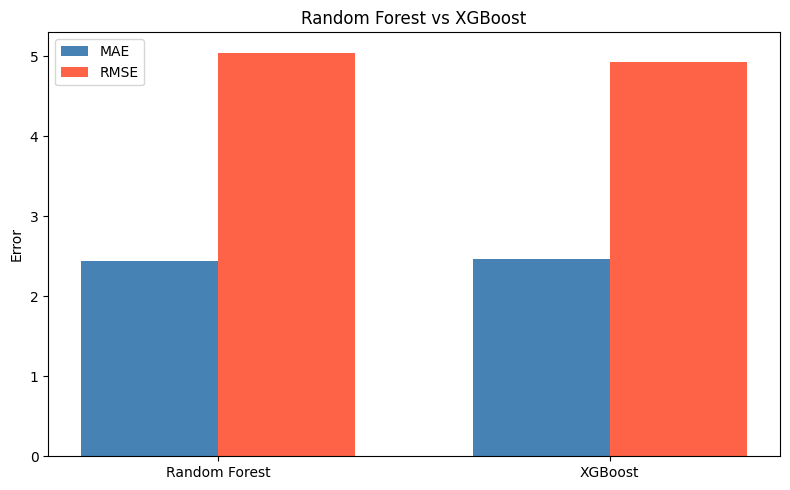

In [13]:
models     = ['Random Forest', 'XGBoost']
mae_scores = [rf_mae,  xgb_mae]
rmse_scores= [rf_rmse, xgb_rmse]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, mae_scores,  width, label='MAE',  color='steelblue')
ax.bar(x + width/2, rmse_scores, width, label='RMSE', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Error')
ax.set_title('Random Forest vs XGBoost')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/plot_model_comparison.png')
plt.show()

Plot Actual vs Predicted

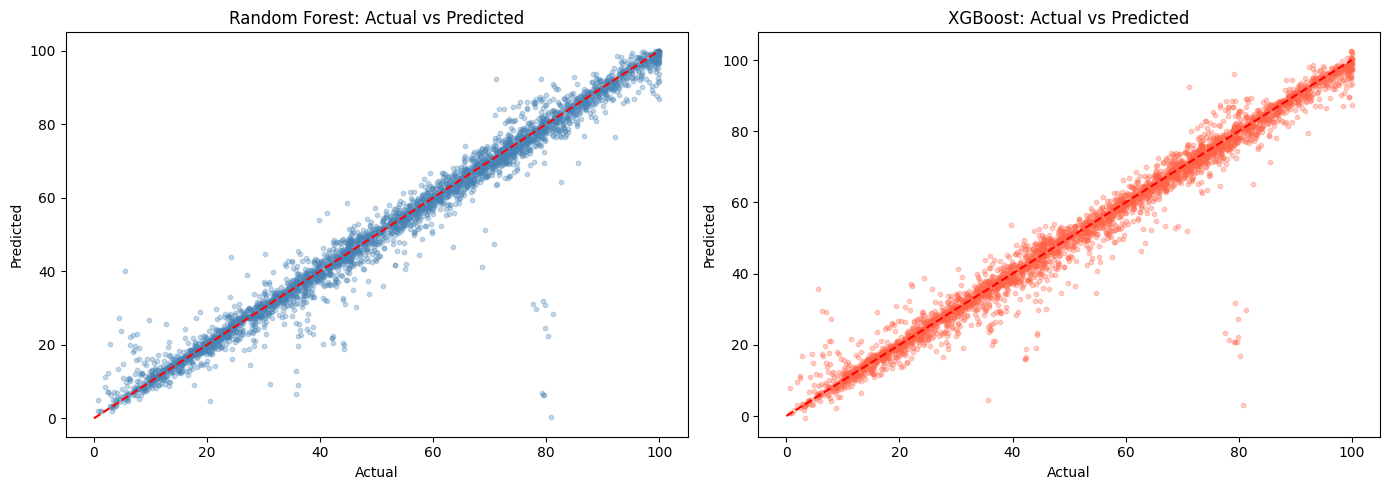

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, rf_preds, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Actual vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, xgb_preds, alpha=0.3, s=10, color='tomato')
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost: Actual vs Predicted')

plt.tight_layout()
plt.savefig('../data/processed/plot_actual_vs_predicted.png')
plt.show()

 Feature Importance

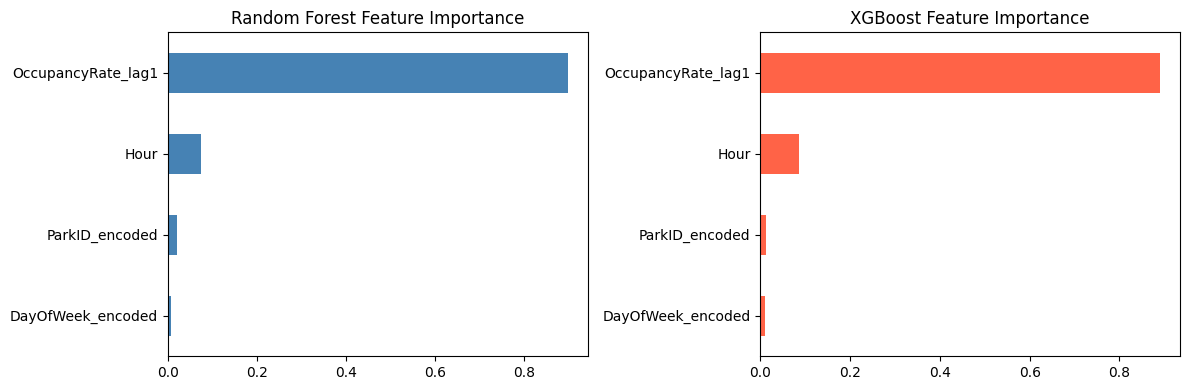

In [15]:
feat_names = X_train.columns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=feat_names).sort_values()
rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')

# XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feat_names).sort_values()
xgb_importance.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.savefig('../data/processed/plot_feature_importance.png')
plt.show()

Pick Best Model and Save It

In [16]:
# Pick model with lower RMSE
if rf_rmse <= xgb_rmse:
    best_model = rf_model
    best_name  = "Random Forest"
else:
    best_model = xgb_model
    best_name  = "XGBoost"

print(f"Best model: {best_name}")

# Save best model
joblib.dump(best_model, '../models/best_model.pkl')
print("Model saved to models/best_model.pkl")

Best model: XGBoost
Model saved to models/best_model.pkl


Quick Prediction Test

In [17]:
# Simulate: Wednesday 8:30 AM, Car Park 0, previous occupancy 45%
sample = pd.DataFrame([{
    'Hour': 8,
    'DayOfWeek_encoded': 2,
    'ParkID_encoded': 0,
    'OccupancyRate_lag1': 45.0
}])

prediction = best_model.predict(sample)[0]
print(f"Predicted occupancy rate: {prediction:.1f}%")

Predicted occupancy rate: 26.4%
